In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn

from models import get_model

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader



In [2]:
def simple_lr_finder(model, optimizer, criterion, train_loader, 
                     start_lr=1e-5, end_lr=1, num_iter=100, device='cuda', title=''):
    """
    Runs a Learning Rate Finder experiment.
    """
    model.to(device)
    model.train()
    model.eval()
    
    # Calculate the exponential factor to increase LR
    lr_mult = (end_lr / start_lr) ** (1 / num_iter)
    
    # Reset optimizer with start_lr
    for g in optimizer.param_groups:
        g['lr'] = start_lr
        
    lrs = []
    losses = []
    best_loss = float('inf')
    avg_loss = 0
    beta = 0.9  # Smoothing factor for the loss
    
    current_lr = start_lr
    batch_num = 0
    
    print(f"Starting LR Finder: {num_iter} steps...")

    for i, (inputs, targets) in enumerate(train_loader):
        batch_num += 1
        inputs, targets = inputs.to(device), targets.to(device)
        
        # 1. Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # 2. Smooth the loss (Exponential Moving Average)
        # This prevents the plot from being too jittery to read
        current_loss = loss.item()
        avg_loss = beta * avg_loss + (1 - beta) * current_loss
        smoothed_loss = avg_loss / (1 - beta**batch_num)
        
        # Stop if loss explodes (divergence)
        if batch_num > 1 and smoothed_loss > 4 * best_loss:
            print(f"Stopping early: Loss exploded at LR {current_lr:.4f}")
            break
        
        if smoothed_loss < best_loss or batch_num == 1:
            best_loss = smoothed_loss
            
        # Store values for plotting
        losses.append(smoothed_loss)
        lrs.append(current_lr)
        
        # 3. Backward pass
        loss.backward()
        optimizer.step()
        
        # 4. Update Learning Rate
        current_lr *= lr_mult
        for g in optimizer.param_groups:
            g['lr'] = current_lr
            
        if batch_num >= num_iter:
            break

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.plot(lrs, losses)
    plt.xscale('log')
    plt.xlabel('Learning Rate (Log Scale)')
    plt.ylabel('Loss (Smoothed)')
    plt.title('Learning Rate Finder' + title)
    plt.grid(True, which="both", ls="-")
    plt.show()

    return lrs, losses

In [3]:
device = torch.device(f"cuda:4" if torch.cuda.is_available() else "cpu")
batch_size = 512

/tmp/ipykernel_1880974/2506151474.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_train, y_train, X_test, y_test = torch.load('cifar10_resnet18_features.pt')


Converting model to LoRA (Rank=4)...
Starting LR Finder: 98 steps...
Stopping early: Loss exploded at LR 0.3017


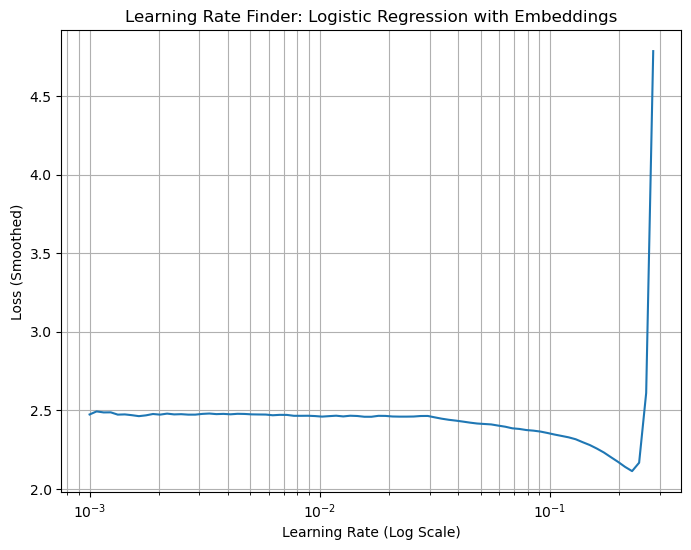

In [4]:
X_train, y_train, X_test, y_test = torch.load('cifar10_resnet18_features.pt')
input_dim = X_train.shape[1]

from torch.utils.data import TensorDataset, DataLoader

# Create simple dataloaders for the embeddings
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

model = get_model('logreg', device, use_lora=True, lora_rank=4, input_dim = input_dim)


trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(trainable_params)
criterion = nn.CrossEntropyLoss()

lrs, losses = simple_lr_finder(model, optimizer, criterion, train_loader, start_lr=1e-3, end_lr=1, num_iter= len(train_loader), device=device, title=': Logistic Regression with Embeddings')

In [5]:
# input_dim = 32 * 32 * 3

# transform = transforms.Compose([
#             transforms.ToTensor(),
#             transforms.Normalize((0.5,), (0.5,)),
#             transforms.Lambda(lambda x: x.view(-1)) 
#         ])


# train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)



# train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
# test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
# model = get_model('logreg', device, use_lora=True, lora_rank=4, input_dim = input_dim)


# trainable_params = [p for p in model.parameters() if p.requires_grad]
# optimizer = optim.SGD(trainable_params, weight_decay=0)
# criterion = nn.CrossEntropyLoss()

# lrs, losses = simple_lr_finder(model, optimizer, criterion, train_loader, start_lr=1e-3, end_lr=1, num_iter= len(train_loader), device=device, title=': Logistic Regression')

Files already downloaded and verified
Files already downloaded and verified
Converting model to LoRA (Rank=20)...
Starting LR Finder: 98 steps...


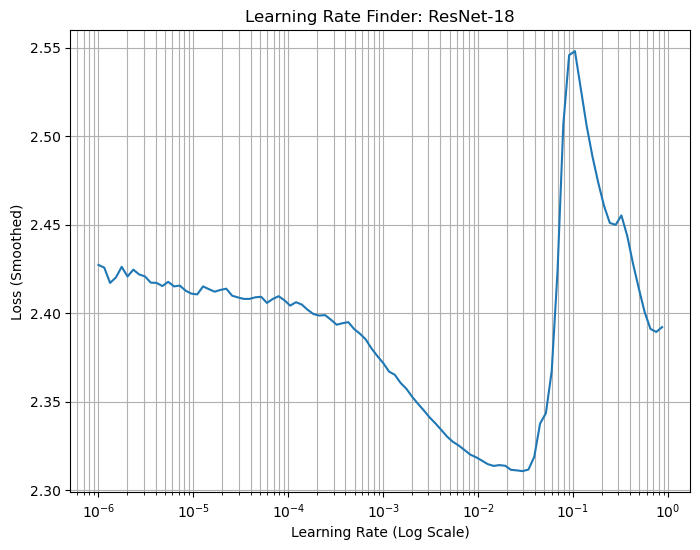

In [6]:
transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)



train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
model = get_model('resnet18', device, use_lora=True, lora_rank=20, input_dim = input_dim)



trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(trainable_params)
criterion = nn.CrossEntropyLoss()

lrs, losses = simple_lr_finder(model, optimizer, criterion, train_loader, start_lr=1e-6, end_lr=1, num_iter=len(train_loader), device=device, title=': ResNet-18')

In [7]:
1/100

0.01